# Prediction for Picnic Weather
## Apply Model for Prediction

Apply fitted model with Weather data from API request

Use stored XGB model

---

## 1. Load Modules & Load Data



In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from core.data import load_from_kaggle

# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# GeoPy with Nominatim to estimate lat, lon from city name
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os
import time
import requests     # um die OpenAPI für Höhenangaben bei lat, lon abzufragen

# Meteostat for weather data
from datetime import date
import meteostat as ms

# Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib   # um Modelle zu speichern und zu laden
# from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance

# import module for Score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score

c:\Users\Trainee\Documents\dpp\portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




## 2. Load Model from File



In [2]:
# Load model from file
def load_model(model_name):
    model_path = f'{model_name}.joblib'
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        print(f"✅ Modell '{model_name}' erfolgreich geladen.")
        return model
    else:
        print(f"❌ Modell '{model_name}' nicht gefunden unter: {model_path}")
        return None


In [ ]:

file_weather_FS    = '../data/processed/weather_FS_lat_lon_elevation.csv'
file_weather_meteostat    = '../data/processed/weather_meteostat_lat_lon_elevation.csv'

# For extended analysis, you could also load the complete dataset if needed
weather_FS = pd.read_csv(file_weather_FS, 
                           delimiter=',', encoding='ascii', parse_dates=['DATE'])
print(f"📊 Geladene Datei: {file_weather_FS}")
print(f"📏 Shape: {weather_FS.shape[0]:,} Zeilen × {weather_FS.shape[1]} Spalten\n")

# For extended analysis, you could also load the complete dataset if needed
meteostat = pd.read_csv(file_weather_meteostat, 
                           delimiter=',', encoding='ascii', parse_dates=['DATE'])
print(f"📊 Geladene Datei: {file_weather_meteostat}")
print(f"📏 Shape: {meteostat.shape[0]:,} Zeilen × {meteostat.shape[1]} Spalten\n")

# Convert the DATE column to datetime. The DATE is given as an integer (likely in YYYYMMDD format)
# for df in [weather_FS, meteostat]:
#     df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d', errors='coerce')

print('Data loaded and DATE column converted to datetime.')

display(weather_FS.sample(3))
meteostat.sample(3)

weather_FS.info()
meteostat.info()



---

## 3. Request Weather Data from Meteostat API



In [44]:
# Function to request Weather Data from Meteostat API for a cityname and a date(one day) and 
# return lat, lon, elevation, and daily weather values
from datetime import datetime


def get_weather_data_meteostat(city_name, date_str):
    geolocator = Nominatim(user_agent="weather_app")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
    
    location = geocode(city_name)
    if location is None:
        print(f"❌ Fehler: Stadt '{city_name}' nicht gefunden.")
        return None
    
    lat, lon = location.latitude, location.longitude
    print(f"📍 Geokodierung für '{city_name}': lat={lat}, lon={lon}")
    
    # Open-Meteo API für Höhenangaben
    elevation_url = f"https://api.open-meteo.com/v1/elevation?latitude={lat}&longitude={lon}"
    try:
        response = requests.get(elevation_url)
        response.raise_for_status()
        elevation_data = response.json()
        elevation = elevation_data.get('elevation', None)
        print(f"⛰️ Höhenangabe für '{city_name}': {elevation} m")
    except requests.RequestException as e:
        print(f"❌ Fehler bei der Höhenabfrage: {e}")
        elevation = None
    
    # Meteostat API für Wetterdaten
    start_date = end_date = datetime.strptime(date_str, '%Y-%m-%d') # date(date_str)
    try:
        # data = ms.daily(ms.Point(lat, lon), start_date, end_date)
        # data = data.fetch()
        # Specify location and time range
        POINT = ms.Point(lat, lon, elevation)
        # START = date(2000, 1, 1)
        # END = date(2010, 1, 1)
        # Get nearby weather stations
        stations = ms.stations.nearby(POINT, limit=4)

        # Get daily data & perform interpolation
        ts = ms.daily(stations, start_date, end_date)
        data = ms.interpolate(ts, POINT).fetch()

        # Reset index so the time index becomes a normal column and can be renamed
        data = data.reset_index()

        # Rename columns to match weather_FS naming
        data = data.rename(columns={
            'time': 'DATE',
            'temp': 'temp_mean',
            'tmin': 'temp_min',
            'tmax': 'temp_max',
            'rhum': 'humidity',
            'prcp': 'precipitation',
            'snwd': 'snowfall',
            'wspd': 'wind_speed',
            'pres': 'pressure',
            'tsun': 'sunshine',
            'cldc': 'cloud_cover'
        })

        # Convert sunshine from minutes to hours
        if 'sunshine' in data.columns:
            data['sunshine'] = data['sunshine'] / 60

        if data.empty:
            print(f"⚠️ Keine Wetterdaten für '{city_name}' am {date_str} gefunden.")
            return None
        else:
            print(f"✅ Wetterdaten für '{city_name}' am {date_str} gefunden: {data.columns.tolist()}")
            display(data)
        



        weather_info = {
            'city': city_name,
            'date': date_str,
            'lat': lat,
            'lon': lon,
            'elevation': elevation,
            'temperature': data['temp_mean'].iloc[0] if 'temp_mean' in data.columns else None,
            'precipitation': data['precipitation'].iloc[0] if 'precipitation' in data.columns else None,
            'wind_speed': data['wind_speed'].iloc[0] if 'wind_speed' in data.columns else None,
            # Weitere relevante Wetterparameter können hier hinzugefügt werden
        }
        
        print(f"✅ Wetterdaten für '{city_name}' am {date_str} erfolgreich abgerufen.")
        return weather_info
    except Exception as e:
        print(f"❌ Fehler bei der Wetterabfrage: {e}")
        return None


In [62]:
# Function to request Weather Data from Open-Meteo API for a cityname and a date(one day) and 
# return lat, lon, elevation, and daily weather values

# pip install openmeteo-requests
# pip install requests-cache retry-requests numpy pandas

import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

def get_weather_data_openmeteo(city_name, date_str):
    geolocator = Nominatim(user_agent="weather_app")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
    
    location = geocode(city_name)
    if location is None:
        print(f"❌ Fehler: Stadt '{city_name}' nicht gefunden.")
        return None
    
    lat, lon = location.latitude, location.longitude
    print(f"📍 Geokodierung für '{city_name}': lat={lat}, lon={lon}")
    
    # Open-Meteo API für Höhenangaben
    elevation_url = f"https://api.open-meteo.com/v1/elevation?latitude={lat}&longitude={lon}"
    try:
        response = requests.get(elevation_url)
        response.raise_for_status()
        elevation_data = response.json()
        elevation = elevation_data.get('elevation', None)
        print(f"⛰️ Höhenangabe für '{city_name}': {elevation} m")
    except requests.RequestException as e:
        print(f"❌ Fehler bei der Höhenabfrage: {e}")
        elevation = None
    
    # Meteostat API für Wetterdaten
    # start_date = end_date = datetime.strptime(date_str, '%Y-%m-%d') # date(date_str)

    # Setup the Open-Meteo API client with cache and retry on error
    cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
    retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
    openmeteo = openmeteo_requests.Client(session = retry_session)

    # Make sure all required weather variables are listed here
    # The order of variables in hourly or daily is important to assign them correctly below
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        # "daily": ["temperature_2m_max", "temperature_2m_min", "sunshine_duration", "precipitation_sum", "precipitation_probability_max", "temperature_2m_mean", "relative_humidity_2m_mean", "snowfall_sum", "wind_gusts_10m_mean", "wind_speed_10m_mean", "surface_pressure_mean", "cloud_cover_mean"],
        "daily": ["temperature_2m_max", "temperature_2m_min", "sunshine_duration", "precipitation_sum", 
                  "precipitation_probability_max", "temperature_2m_mean", "relative_humidity_2m_mean", 
                  "snowfall_sum", "wind_gusts_10m_mean", "wind_speed_10m_mean", "surface_pressure_mean", 
                  "cloud_cover_mean", "shortwave_radiation_sum", "precipitation_hours"],
        "start_date": date_str,
        "end_date": date_str,
        # "forecast_days": 16,
    }
    responses = openmeteo.weather_api(url, params = params)

    # Process first location. Add a for-loop for multiple locations or weather models
    response = responses[0]
    print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
    print(f"Elevation: {response.Elevation()} m asl")
    print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

    # Process daily data. The order of variables needs to be the same as requested.
    daily = response.Daily()
    daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
    daily_temperature_2m_min = daily.Variables(1).ValuesAsNumpy()
    daily_sunshine_duration = daily.Variables(2).ValuesAsNumpy()
    daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()
    daily_precipitation_probability_max = daily.Variables(4).ValuesAsNumpy()
    daily_temperature_2m_mean = daily.Variables(5).ValuesAsNumpy()
    daily_relative_humidity_2m_mean = daily.Variables(6).ValuesAsNumpy()
    daily_snowfall_sum = daily.Variables(7).ValuesAsNumpy()
    daily_wind_gusts_10m_mean = daily.Variables(8).ValuesAsNumpy()
    daily_wind_speed_10m_mean = daily.Variables(9).ValuesAsNumpy()
    daily_surface_pressure_mean = daily.Variables(10).ValuesAsNumpy()
    daily_cloud_cover_mean = daily.Variables(11).ValuesAsNumpy()
    daily_shortwave_radiation_sum = daily.Variables(12).ValuesAsNumpy()
    daily_precipitation_hours = daily.Variables(13).ValuesAsNumpy()

    daily_data = {
        "date": pd.date_range(
            start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = daily.Interval()),
            inclusive = "left"
        )
    }

    daily_data["DATE"] = datetime.strptime(date_str, '%Y-%m-%d')
    daily_data["MONTH"] = datetime.strptime(date_str, '%Y-%m-%d').month
    daily_data["temp_mean"] = daily_temperature_2m_mean
    daily_data["temp_max"] = daily_temperature_2m_max
    daily_data["temp_min"] = daily_temperature_2m_min
    daily_data["cloud_cover"] = daily_cloud_cover_mean
    daily_data["wind_speed"] = daily_wind_speed_10m_mean
    daily_data["sunshine"] = daily_sunshine_duration / 3600  # Convert seconds to hours
    daily_data["wind_gust"] = daily_wind_gusts_10m_mean
    daily_data["humidity"] = daily_relative_humidity_2m_mean
    daily_data["pressure"] = daily_surface_pressure_mean
    daily_data["global_radiation"] = daily_shortwave_radiation_sum
    daily_data["lat"] = lat
    daily_data["lon"] = lon
    daily_data["elevation"] = elevation
    daily_data["precipitation"] = daily_precipitation_sum
    daily_data["precipitation_probability_max"] = daily_precipitation_probability_max
    daily_data["snowfall"] = daily_snowfall_sum
    daily_data["precipitation_hours"] = daily_precipitation_hours

    daily_dataframe = pd.DataFrame(data = daily_data)
    # print("\nDaily data\n", daily_dataframe)
    display(daily_dataframe)
    
    return daily_dataframe


In [63]:

# get_weather_data_meteostat('Frankfurt', '2026-05-14')
df_picnic = get_weather_data_openmeteo('Frankfurt', '2026-05-14')
df_picnic

📍 Geokodierung für 'Frankfurt': lat=50.1106444, lon=8.6820917
⛰️ Höhenangabe für 'Frankfurt': [103.0] m
Coordinates: 50.119998931884766°N 8.680000305175781°E
Elevation: 103.0 m asl
Timezone difference to GMT+0: 0s


,date,DATE,MONTH,temp_mean,temp_max,temp_min,cloud_cover,wind_speed,sunshine,wind_gust,humidity,pressure,global_radiation,lat,lon,elevation,precipitation,precipitation_probability_max,snowfall,precipitation_hours
0,2026-05-14 00:00:00+00:00,2026-05-14,5,12.537002,16.9,8.35,86.96875,11.843075,14.964067,37.942497,69.09758,993.858704,20.92,50.110644,8.682092,103.0,0.0,54.0,0.0,0.0


,date,DATE,MONTH,temp_mean,temp_max,temp_min,cloud_cover,wind_speed,sunshine,wind_gust,humidity,pressure,global_radiation,lat,lon,elevation,precipitation,precipitation_probability_max,snowfall,precipitation_hours
0,2026-05-14 00:00:00+00:00,2026-05-14,5,12.537002,16.9,8.35,86.96875,11.843075,14.964067,37.942497,69.09758,993.858704,20.92,50.110644,8.682092,103.0,0.0,54.0,0.0,0.0


In [60]:
df_picnic.sunshine +1

0    15.964067
Name: sunshine, dtype: float32

In [53]:
europe_features = {
    'EUROall': ['cloud_cover', 'wind_speed', 'wind_gust', 'humidity', 'pressure', 'global_radiation',
              'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max', 'lat', 'lon', 'elevation'],
    # 'EUROselect': ['MONTH', 'precipitation', 'temp_mean', 'temp_max', 'lat', 'lon', 'elevation'],
    'EUROselect': ['MONTH', 'temp_mean', 'temp_max', 'cloud_cover', 'wind_speed', 'sunshine', 
                   'wind_gust', 'humidity', 'pressure', 'global_radiation', 'lat', 'lon', 'elevation'],
    'EUROmin': ['MONTH', 'temp_mean', 'temp_max', 'lat', 'lon', 'elevation'],
              }

In [64]:
model = load_model('model_xgb_EURO')

picnic = model.predict(pd.DataFrame(df_picnic[europe_features['EUROselect']]))

picnic
        # X = df_weather[feature_cols]
        # y = df_weather[target_col]

        # clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        # clf.fit(X_train, y_train)

✅ Modell 'model_xgb_EURO' erfolgreich geladen.


array([0])

In [3]:
# Func Def: Overview(df) Übersicht entwerfen, um immer mal wieder einen schnellen Überblick über die wichtigsten "Metadaten" zu bekommen
def overview(df):
    '''
    Erstelle einen Überblick über einige wichtige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        None
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,
                          'total': df.count(),
                          'missing_n': df.isna().sum(),
                          'missing_%': df.isna().mean()*100,
                          'uniques_n': df.nunique(),
                          'uniques': [df[col].unique() for col in df.columns]
                         }))

In [4]:
overview(weather_FS)
overview(meteostat)

,dtype,total,missing_n,missing_%,uniques_n,uniques
DATE,datetime64[ns],62118,0,0.000000,3654,"[2000-01-01 00:00:00, 2000-01-02 00:00:00, 200..."
MONTH,int64,62118,0,0.000000,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
cloud_cover,float64,43848,18270,29.411765,11,"[8.0, 5.0, 7.0, 3.0, 4.0, 1.0, 0.0, 6.0, 2.0, ..."
wind_speed,float64,43848,18270,29.411765,140,"[nan, 2.5, 3.7, 6.1, 3.8, 4.0, 5.2, 4.8, 4.3, ..."
wind_gust,float64,25578,36540,58.823529,271,"[nan, 8.0, 9.0, 13.0, 15.0, 12.0, 11.0, 7.0, 5..."
humidity,float64,54810,7308,11.764706,84,"[0.89, 0.87, 0.81, 0.79, 0.9, 0.85, 0.84, 0.88..."
pressure,float64,51156,10962,17.647059,692,"[1.0286, 1.0318, 1.0314, 1.0262, 1.0246, 1.024..."
global_radiation,float64,54810,7308,11.764706,413,"[0.2, 0.25, 0.5, 0.63, 0.51, 0.56, 0.54, 0.11,..."
precipitation,float64,62118,0,0.000000,526,"[0.03, 0.0, 0.35, 0.07, 0.65, 0.09, 0.12, 0.42..."
sunshine,float64,47502,14616,23.529412,185,"[0.0, 3.7, 6.9, 5.7, 4.3, 7.5, 7.6, 2.8, 0.3, ..."


,dtype,total,missing_n,missing_%,uniques_n,uniques
DATE,datetime64[ns],58379,0,0.000000,3654,"[2000-01-01 00:00:00, 2000-01-02 00:00:00, 200..."
temp_mean,float64,57890,489,0.837630,467,"[2.7, 3.5, 2.2, 4.0, 5.6, 4.2, 4.4, 5.3, 1.9, ..."
temp_min,float64,57331,1048,1.795166,446,"[1.8, 2.9, 0.3, 0.7, 4.1, 2.2, 2.0, 4.2, 1.6, ..."
temp_max,float64,57777,602,1.031193,510,"[4.2, 5.1, 5.2, 7.9, 8.9, 7.3, 6.5, 8.7, 5.9, ..."
humidity,float64,54346,4033,6.908306,81,"[95.0, 92.0, 86.0, 85.0, 96.0, 91.0, 97.0, 87...."
precipitation,float64,51333,7046,12.069409,511,"[0.4, 0.0, 3.4, 0.7, 0.1, 6.6, 0.9, 0.3, 1.4, ..."
snowfall,float64,24509,33870,58.017438,135,"[1.0, 0.0, 5.0, 4.0, 2.0, 6.0, 9.0, 7.0, 3.0, ..."
wind_speed,float64,54295,4084,6.995666,474,"[7.4, 9.6, 11.8, 10.0, 6.8, 10.4, 7.8, 6.4, na..."
pressure,float64,47277,11102,19.017112,667,"[1028.0, 1031.4, 1031.2, 1026.1, 1024.6, 1024...."
sunshine,float64,17001,41378,70.878227,853,"[0.1, 2.6, 1.9, 6.5, 2.9, 4.4, 0.0, 5.4, 7.4, ..."


In [5]:
# col_names = ['Date', 'Month',
#              'cloud_cover', 'humidity', 'pressure', 'global_radiation',
#              'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max',
#              'lat', 'lon', 'city']

# cities = ['BASEL', 'BUDAPEST', 'DE', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'LJUBLJANA',
#           'MAASTRICHT', 'MALMO', 'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN',
#           'SONNBLICK', 'STOCKHOLM', 'TOURS']

# df_basel = weather_full.loc[:,['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
#                                'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max']]
# df_basel['lat'] = 47.5596
# df_basel['lon'] = 7.5886
# df_basel['city'] = 'Basel'
# df_basel.columns = col_names
# df_basel

In [6]:
weather_FS

,DATE,MONTH,cloud_cover,wind_speed,wind_gust,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,city,picnic_weather,lat,lon,elevation
0,2000-01-01,1,8.0,NaN,NaN,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9,BASEL,False,47.558108,7.587826,263.0
1,2000-01-02,1,8.0,NaN,NaN,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8,BASEL,False,47.558108,7.587826,263.0
2,2000-01-03,1,5.0,NaN,NaN,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8,BASEL,False,47.558108,7.587826,263.0
3,2000-01-04,1,7.0,NaN,NaN,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5,BASEL,False,47.558108,7.587826,263.0
4,2000-01-05,1,5.0,NaN,NaN,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6,BASEL,False,47.558108,7.587826,263.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62113,2009-12-28,12,NaN,3.7,NaN,0.95,1.0011,0.22,1.50,NaN,6.2,1.8,10.6,TOURS,False,47.390047,0.688927,55.0
62114,2009-12-29,12,NaN,5.3,NaN,0.89,0.9966,0.24,0.40,NaN,10.4,6.2,14.5,TOURS,False,47.390047,0.688927,55.0
62115,2009-12-30,12,NaN,3.8,NaN,0.88,0.9939,0.24,1.00,NaN,10.0,8.7,11.3,TOURS,False,47.390047,0.688927,55.0
62116,2009-12-31,12,NaN,4.2,NaN,0.88,0.9933,0.58,0.02,NaN,8.5,6.2,10.9,TOURS,False,47.390047,0.688927,55.0


In [7]:
weather_FS.city.unique()

array(['BASEL', 'BUDAPEST', 'DE_BILT', 'DRESDEN', 'DUSSELDORF',
       'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MALMO',
       'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN', 'SONNBLICK',
       'STOCKHOLM', 'TOURS'], dtype=object)



---

## Base Model for Picnic Weather Prediction

In [8]:
# Function to create, fit and evaluate a model for a CITY with RandomForestClassifier

def fit_model_for_city(city_name, df_weather, feature_cols, target_col, save_plot=False, show_plot=True):

    if city_name == 'EURO':
        X = df_weather[feature_cols]
        y = df_weather[target_col]
    else:
        X = df_weather[df_weather['city'] == city_name][feature_cols]
        y = df_weather[df_weather['city'] == city_name][target_col]

    # overview(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train a Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(X_test)

    # Calculate prediction accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print('Prediction accuracy for ' + city_name + ' picnic weather:', accuracy)

    # Calculate ROC curve and AUC
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('AUC:', roc_auc)

    # Compute permutation importance
    perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
    importances = perm_importance.importances_mean

    # Create a DataFrame for feature importance
    feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    feature_importance_df.sort_values(by='importance', ascending=True, inplace=True)

    print('Permutation importance calculated for the features.')

    print(f'RandomForestClassifier \t\t\t|\t TEST \t\t|\t TRAIN')
    print(f'-------------------------------------------------------------------------------------')
    print(f'True #IsBad:     \t\t\t|\t {(y_test==1).sum()} \t\t|\t {(y_train==1).sum()}')
    print(f'True #NotBad:    \t\t\t|\t {(y_test==0).sum()} \t\t|\t {(y_train==0).sum()}')
    print(f'F1-Score:        \t\t\t|\t {f1_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{f1_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'precision_score: \t\t\t|\t {precision_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{precision_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'recall_score:    \t\t\t|\t {recall_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{recall_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'accuracy_score:  \t\t\t|\t {accuracy_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{accuracy_score(y_train, clf.predict(X_train))*100:.2f} %')

    if save_plot:
        os.makedirs('../plots', exist_ok=True)

    # Model Evaluation and Visualization
    # Plot ROC Curve
    roc_fig = plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for ' + city_name + ' Picnic Weather Prediction')
    plt.legend(loc='lower right')
    if save_plot:
        roc_fig.savefig(f'../plots/ROC_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(roc_fig)

    # Plot Confusion Matrix using a heatmap
    cm = confusion_matrix(y_test, y_pred)
    cm_fig = plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix ' + city_name)
    if save_plot:
        cm_fig.savefig(f'../plots/Confusion_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(cm_fig)

    # Plot Permutation Importance
    imp_fig = plt.figure(figsize=(8, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
    plt.xlabel('Mean Importance')
    plt.title('Permutation Importance of ' + city_name + ' Weather Features')
    if save_plot:
        imp_fig.savefig(f'../plots/Importance_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(imp_fig)



In [9]:
# Function to create, fit and evaluate a model for a CITY with XGBoost
def fit_model_xgb(city_name, df_weather, feature_cols, target_col, save_plot=False, show_plot=True, save_model=False):

    if city_name == 'EURO':
        X = df_weather[feature_cols]
        y = df_weather[target_col]
    else:
        X = df_weather[df_weather['city'] == city_name][feature_cols]
        y = df_weather[df_weather['city'] == city_name][target_col]

    if isinstance(y, pd.DataFrame) and y.shape[1] == 1:
        y = y.iloc[:, 0]

    # overview(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train an XGBoost classifier
    clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    clf.fit(X_train, y_train)

    # Save the trained model to a joblib file
    if save_model:
        model_path = f'model_xgb_{city_name}.joblib'
        joblib.dump(clf, model_path)
        print(f'Model saved to: {model_path}')

    # Make predictions on the test set
    y_pred = clf.predict(X_test)

    # Calculate prediction accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print('Prediction accuracy for ' + city_name + ' picnic weather with XGBoost:', accuracy)

    # Calculate ROC curve and AUC
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('AUC:', roc_auc)

    # Compute permutation importance
    perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
    importances = perm_importance.importances_mean

    # Create a DataFrame for feature importance
    feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    feature_importance_df.sort_values(by='importance', ascending=True, inplace=True)

    print('Permutation importance calculated for the features.')

    print(f'XGBClassifier \t\t\t|\t TEST \t\t|\t TRAIN')
    print(f'-------------------------------------------------------------------------------------')
    print(f'True #IsBad:     \t\t\t|\t {(y_test==1).sum()} \t\t|\t {(y_train==1).sum()}')
    print(f'True #NotBad:    \t\t\t|\t {(y_test==0).sum()} \t\t|\t {(y_train==0).sum()}')
    print(f'F1-Score:        \t\t\t|\t {f1_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{f1_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'precision_score: \t\t\t|\t {precision_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{precision_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'recall_score:    \t\t\t|\t {recall_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{recall_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'accuracy_score:  \t\t\t|\t {accuracy_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{accuracy_score(y_train, clf.predict(X_train))*100:.2f} %')

    if save_plot:
        os.makedirs('../plots', exist_ok=True)

    # Model Evaluation and Visualization
    roc_fig = plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for ' + city_name + ' Picnic Weather Prediction (XGBoost)')
    plt.legend(loc='lower right')
    if save_plot:
        roc_fig.savefig(f'../plots/ROC_XGB_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(roc_fig)

    cm = confusion_matrix(y_test, y_pred)
    cm_fig = plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix ' + city_name + ' (XGBoost)')
    if save_plot:
        cm_fig.savefig(f'../plots/Confusion_XGB_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(cm_fig)

    imp_fig = plt.figure(figsize=(8, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
    plt.xlabel('Mean Importance')
    plt.title('Permutation Importance of ' + city_name + ' Weather Features (XGBoost)')
    if save_plot:
        imp_fig.savefig(f'../plots/Importance_XGB_{city_name}.png', bbox_inches='tight')
        plt.close(imp_fig)

    if show_plot:
        plt.show()

In [10]:
staedte_features = {
    # 'BASEL': ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
    #           'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max'],
    'BASEL': ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
              'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max'],
    'DE_BILT': ['DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure', 'DE_BILT_global_radiation',
                'DE_BILT_precipitation', 'DE_BILT_sunshine', 'DE_BILT_temp_mean',
                'DE_BILT_temp_min', 'DE_BILT_temp_max'],
    'DRESDEN': ['DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
                'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
                'DRESDEN_temp_min', 'DRESDEN_temp_max'],
    'DUSSELDORF': ['DUSSELDORF_cloud_cover', 'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
                   'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation', 'DUSSELDORF_sunshine',
                   'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min', 'DUSSELDORF_temp_max'],
    'HEATHROW': ['HEATHROW_cloud_cover', 'HEATHROW_humidity', 'HEATHROW_pressure', 'HEATHROW_global_radiation',
                 'HEATHROW_precipitation', 'HEATHROW_sunshine', 'HEATHROW_temp_mean',
                 'HEATHROW_temp_min', 'HEATHROW_temp_max'],
    'KASSEL': ['KASSEL_humidity', 'KASSEL_pressure', 'KASSEL_global_radiation', 'KASSEL_precipitation',
               'KASSEL_sunshine', 'KASSEL_temp_mean', 'KASSEL_temp_min', 'KASSEL_temp_max'],
    'MAASTRICHT': ['MAASTRICHT_cloud_cover', 'MAASTRICHT_humidity', 'MAASTRICHT_pressure', 'MAASTRICHT_global_radiation',
                   'MAASTRICHT_precipitation', 'MAASTRICHT_sunshine', 'MAASTRICHT_temp_mean', 'MAASTRICHT_temp_min',
                   'MAASTRICHT_temp_max'],
    'MALMO': ['MALMO_precipitation', 'MALMO_temp_mean', 'MALMO_temp_min', 'MALMO_temp_max'],
    'MUENCHEN': ['MUENCHEN_cloud_cover', 'MUENCHEN_humidity', 'MUENCHEN_pressure', 'MUENCHEN_global_radiation',
                 'MUENCHEN_precipitation', 'MUENCHEN_sunshine', 'MUENCHEN_temp_mean', 'MUENCHEN_temp_min', 'MUENCHEN_temp_max'],
    # 'SONNBLICK': ['SONNBLICK_cloud_cover', 'SONNBLICK_humidity', 'SONNBLICK_global_radiation', 'SONNBLICK_precipitation',
    #               'SONNBLICK_sunshine', 'SONNBLICK_temp_mean', 'SONNBLICK_temp_min', 'SONNBLICK_temp_max'],
    'TOURS': ['TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation', 'TOURS_precipitation',
              'TOURS_temp_mean', 'TOURS_temp_min', 'TOURS_temp_max'],
}




In [11]:
europe_features = {
    'EUROall': ['cloud_cover', 'wind_speed', 'wind_gust', 'humidity', 'pressure', 'global_radiation',
              'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max', 'lat', 'lon', 'elevation'],
    # 'EUROselect': ['MONTH', 'precipitation', 'temp_mean', 'temp_max', 'lat', 'lon', 'elevation'],
    'EUROselect': ['MONTH', 'temp_mean', 'temp_max', 'cloud_cover', 'wind_speed', 'sunshine', 
                   'wind_gust', 'humidity', 'pressure', 'global_radiation', 'lat', 'lon', 'elevation'],
    'EUROmin': ['MONTH', 'temp_mean', 'temp_max', 'lat', 'lon', 'elevation'],
              }

c:\Users\Trainee\Documents\dpp\portfolio\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:41:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model saved to: model_xgb_EURO.joblib
Prediction accuracy for EURO picnic weather with XGBoost: 0.9247424339987121
AUC: 0.9766244787288173
Permutation importance calculated for the features.
XGBClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 3104 		|	 12232
True #NotBad:    			|	 9320 		|	 37462
F1-Score:        			|	 85.42 % 	|	 91.70 %
precision_score: 			|	 82.77 % 	|	 89.52 %
recall_score:    			|	 88.24 % 	|	 93.99 %
accuracy_score:  			|	 92.47 % 	|	 95.81 %


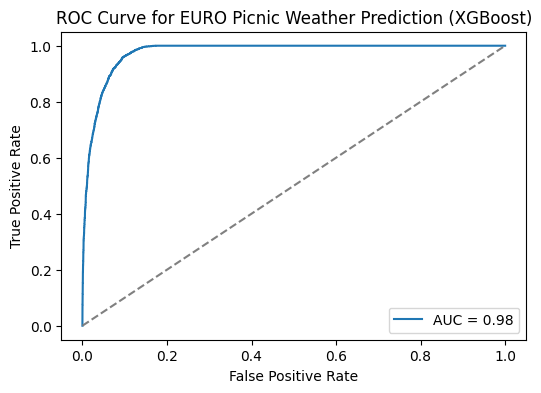

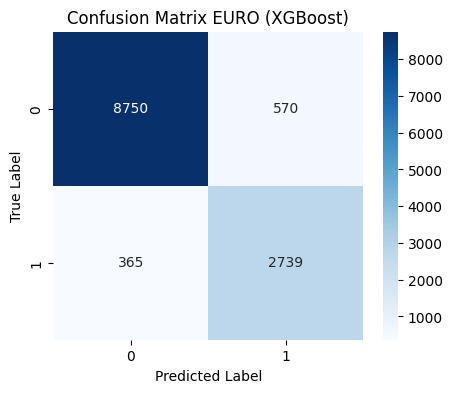

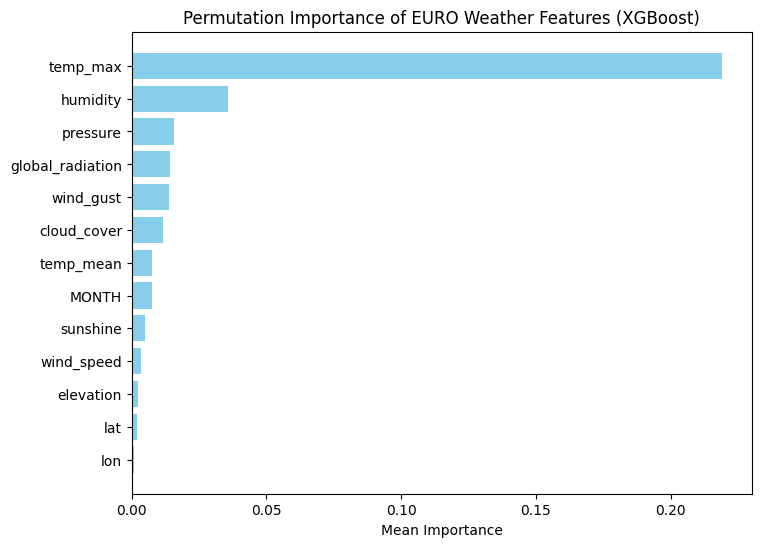

In [12]:
city_name = 'BASEL'
city_name = 'EURO'
# feature_cols = staedte_features[city_name]
# feature_cols = europe_features['EUROmin']
feature_cols = europe_features['EUROselect']
# fit_model_for_city(city_name, weather_FS, feature_cols,
#                    ['picnic_weather'], save_plot=False, show_plot=True)

fit_model_xgb(city_name, weather_FS, feature_cols,
                   ['picnic_weather'], save_plot=False, show_plot=True, save_model=True)


Prediction accuracy for EUROmin picnic weather: 0.8701706374758532
AUC: 0.9397434709747357
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 3104 		|	 12232
True #NotBad:    			|	 9320 		|	 37462
F1-Score:        			|	 75.44 % 	|	 99.30 %
precision_score: 			|	 71.53 % 	|	 98.65 %
recall_score:    			|	 79.80 % 	|	 99.95 %
accuracy_score:  			|	 87.02 % 	|	 99.65 %


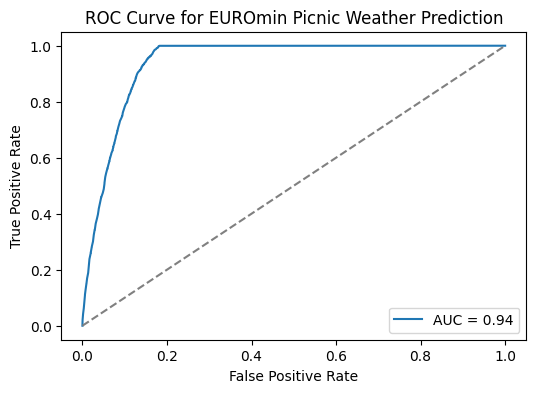

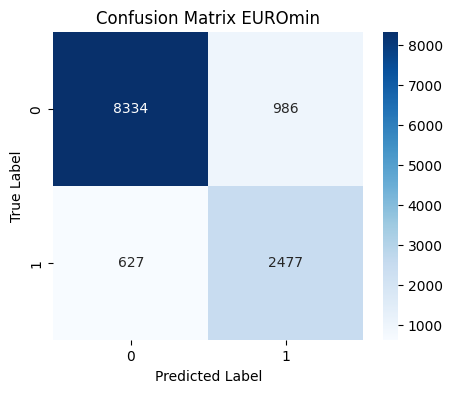

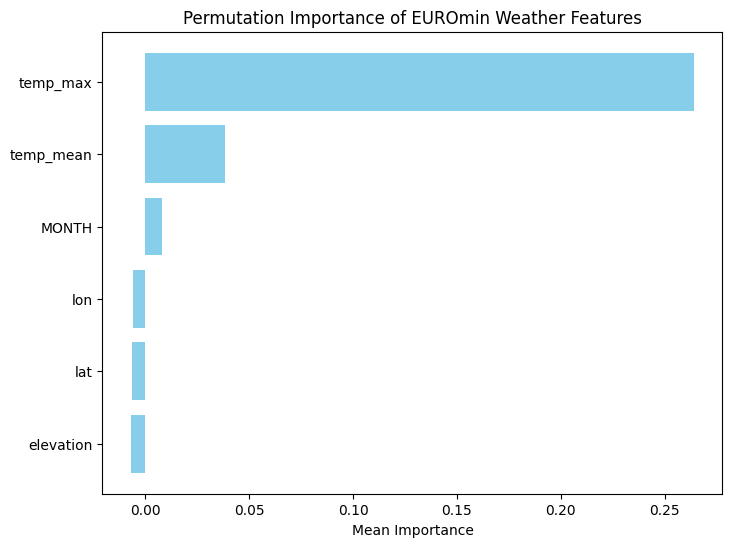

In [ ]:
fit_model_for_city('EUROmin', weather_FS, weather_FS['picnic_weather'],
                   europe_features['EUROmin'], save_plot=True, show_plot=True)
# fit_model_for_city('EUROselect', weather_FS, weather_FS['picnic_weather'],
#                    europe_features['EUROselect'], save_plot=True, show_plot=True)



In [ ]:
# Beispiel: Zugriff per Stadtname
# city_name = 'TOURS'
# feature_cols = staedte_features[city_name]
# fit_model_for_city(city_name, weather_light, picnic_labels, feature_cols)

unique_cities = list(staedte_features.keys()) # weather_FS['city'].unique()

for city in unique_cities:
    fit_model_for_city(city, weather_light, picnic_labels, 
                       staedte_features[city], save_plot=True, show_plot=False)

Prediction accuracy for BASEL picnic weather: 0.9028727770177839
AUC: 0.9652375095179523
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 189 		|	 748
True #NotBad:    			|	 542 		|	 2175
F1-Score:        			|	 81.75 % 	|	 100.00 %
precision_score: 			|	 79.50 % 	|	 100.00 %
recall_score:    			|	 84.13 % 	|	 100.00 %
accuracy_score:  			|	 90.29 % 	|	 100.00 %
Prediction accuracy for DE_BILT picnic weather: 1.0
AUC: 1.0
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 164 		|	 639
True #NotBad:    			|	 567 		|	 2284
F1-Score:        			|	 100.00 % 	|	 100.00 %
precision_score: 			|	 100.00 % 	|	 100.00 %
recall_score:    			|	 100.00 % 	|	 100.00 %
accuracy_score:  			|	 100.

## Model Evaluation and Visualization



---

## 4. Numerische Variablen analysieren





---

## 5. Kategorische Variablen analysieren





---

## 6. Korrelationsanalyse





---

## 7. Fehlende Werte visualisieren





---

## 8. Zusammenfassung & Bewertung

